In [38]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv, find_dotenv
from typing import Dict, Any
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
import os

In [39]:
load_dotenv(find_dotenv())

True

In [40]:
model = ChatOpenAI(
    model="gpt-4o-mini",
    base_url="https://models.inference.ai.azure.com",
    api_key=os.getenv("GITHUB_TOKEN")
)

In [41]:
class BlogState(BaseModel):
    title: str
    outline: str = ""
    content: str = ""
    score: int = 0 
    feedback: str = "" 

class BlogReview(BaseModel):
    score: int = Field(description="Score from 1 to 5", ge=1, le=5)
    feedback: str = Field(description="Constructive feedback for improvement")

In [42]:
def create_outline(state: BlogState) -> Dict[str, Any]:
    topic = state.title
    prompt = f'Generate a detailed outline for a blog, on the topic {topic}'
    outline = model.invoke(prompt).content

    return {"outline": outline}

def create_blog(state: BlogState) -> Dict[str, Any]:
    title = state.title
    outline = state.outline
    prompt = f'Write a detailed blog on the title {title}, using the outline {outline}'
    content = model.invoke(prompt).content

    return {"content": content}


def evaluate(state: BlogState) -> Dict[str, Any]: 
    title = state.title
    content = state.content
    prompt = f"Evaluate this blog post titled '{title}':\n\n{content}"
    
    structured_model = model.with_structured_output(BlogReview)
    review = structured_model.invoke(prompt)
    
    return {
        "score": review.score, 
        "feedback": review.feedback
    }

In [43]:
graph = StateGraph(BlogState)

graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)
graph.add_node("evaluate", evaluate)

graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", "evaluate")
graph.add_edge("evaluate", END)

workflow = graph.compile()

In [44]:
initial_state = {'title': "Rise of AI in India"}

final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': "## Blog Outline: The Rise of AI in India\n\n### Introduction\n- Brief overview of artificial intelligence (AI) and its significance globally\n- Introduction to the Indian context: rapid growth, adoption, and innovation in AI\n- Purpose of the blog: exploring the landscape of AI in India, including opportunities, challenges, and future prospects\n\n### Section 1: The Current Landscape of AI in India\n- **1.1 Definition and Scope of AI**\n  - Explanation of AI, machine learning, and deep learning\n  - Different applications of AI in various sectors (e.g., healthcare, finance, agriculture)\n\n- **1.2 Key Statistics and Trends**\n  - Market growth statistics in the AI sector in India \n  - Comparisons with global AI market trends\n  - Notable AI startups and companies leading in the space\n\n- **1.3 Government Initiatives**\n  - Overview of government policies promoting AI (e.g., Digital India, National AI Strategy)\n  - Establishment of AI rese

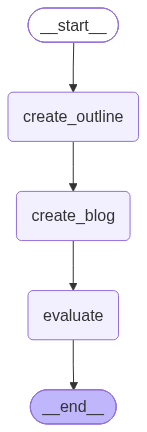

In [45]:
graph.compile()

In [46]:
# print(final_state["title"])
# print(final_state["outline"])
# print(final_state["content"])
print(final_state["score"])
print(final_state["feedback"])

4
Overall, the blog post provides a comprehensive overview of the rise of AI in India, covering key areas such as its impact on various sectors, government initiatives, and future prospects. However, to enhance the post, consider the following suggestions:

1. **Add Visuals**: Incorporating graphs, charts, or images could help break up the text and reinforce the statistics and trends mentioned.
2. **Inclusion of Case Studies**: Providing specific case studies or examples of successful AI implementations in Indian companies would add depth and make the content more relatable.
3. **Explore Ethical Challenges Further**: While ethical and regulatory concerns are mentioned, expanding this section with real-world implications or case studies of AI misuse could engage readers more.
4. **Interactive Elements**: Consider engaging readers with polls or questions in the comments section to encourage more interaction beyond just a call to action at the end.
